# Medical AI Text Detection: Dataset and Linguistic EDA

This notebook audits the HC3 Medicine and MedlinePlus datasets used by the project.
It focuses on data quality, class/source imbalance, text length, stylometric features,
generator provenance, statistical distribution shift, and lexical artifacts.

**Important:** GPU is not required for this notebook. A Colab GPU runtime will still work,
but the computations below are primarily CPU and memory bound.

In [1]:
%pip -q install pandas seaborn matplotlib scipy scikit-learn

In [2]:
import os
import random
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

OUTPUT_DIR = Path("/content/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

## Load the project datasets

Choose one data mode below:

- `upload`: upload the three JSONL files from your computer.
- `drive`: read them from Google Drive.
- `local`: use a checked-out repository under `/content/AI_Detection`.

Required files:

- `hc3_medicine.jsonl`
- `medlineplus_human.jsonl`
- `medlineplus_ai.jsonl`

In [3]:
from pathlib import Path
import json
import pandas as pd

DATA_MODE = "upload"  # "upload", "drive", or "local"

FILES = {
    "hc3": "hc3_medicine.jsonl",
    "medlineplus_human": "medlineplus_human.jsonl",
    "medlineplus_ai": "medlineplus_ai.jsonl",
}

if DATA_MODE == "upload":
    from google.colab import files

    upload_dir = Path("/content/ai_detection_data")
    upload_dir.mkdir(parents=True, exist_ok=True)
    print("Select all three JSONL files.")
    uploaded = files.upload()
    for filename, content in uploaded.items():
        (upload_dir / Path(filename).name).write_bytes(content)
    data_dir = upload_dir
elif DATA_MODE == "drive":
    from google.colab import drive

    drive.mount("/content/drive")
    # Change this if your project is stored elsewhere in Drive.
    data_dir = Path("/content/drive/MyDrive/AI_Detection/data/processed")
elif DATA_MODE == "local":
    data_dir = Path("/content/AI_Detection/data/processed")
else:
    raise ValueError(f"Unsupported DATA_MODE: {DATA_MODE}")

paths = {name: data_dir / filename for name, filename in FILES.items()}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing files: {missing}")

print("Data files:")
for name, path in paths.items():
    print(f"  {name:22s} {path}")

Select all three JSONL files.


Saving medlineplus_ai.jsonl to medlineplus_ai.jsonl
Saving medlineplus_human.jsonl to medlineplus_human.jsonl
Saving hc3_medicine.jsonl to hc3_medicine.jsonl
Data files:
  hc3                    /content/ai_detection_data/hc3_medicine.jsonl
  medlineplus_human      /content/ai_detection_data/medlineplus_human.jsonl
  medlineplus_ai         /content/ai_detection_data/medlineplus_ai.jsonl


In [4]:
def load_jsonl(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


def records_to_frame(records, dataset_group):
    frame = pd.DataFrame(records)
    frame["dataset_group"] = dataset_group
    return frame


hc3 = records_to_frame(load_jsonl(paths["hc3"]), "HC3")
mp_human = records_to_frame(
    load_jsonl(paths["medlineplus_human"]), "MedlinePlus Human"
)
mp_ai = records_to_frame(
    load_jsonl(paths["medlineplus_ai"]), "MedlinePlus AI"
)

df = pd.concat([hc3, mp_human, mp_ai], ignore_index=True, sort=False)
df["analysis_group"] = df["dataset_group"]
hc3_mask = df["dataset_group"].eq("HC3")
hc3_label_names = df.loc[hc3_mask, "label"].map(
    {"human": "Human", "ai": "AI"}
)
if hc3_label_names.isna().any():
    unknown_index = hc3_label_names.index[hc3_label_names.isna()]
    unknown_labels = sorted(df.loc[unknown_index, "label"].unique())
    raise ValueError(f"Unknown HC3 labels: {unknown_labels}")
df.loc[hc3_mask, "analysis_group"] = "HC3 " + hc3_label_names

print(f"Combined rows: {len(df):,}")
display(df.groupby(["analysis_group", "label"]).size().rename("rows").to_frame())
display(df.head(3))

Combined rows: 3,698


,,rows
analysis_group,label,
HC3 AI,ai,1334
HC3 Human,human,1248
MedlinePlus AI,ai,100
MedlinePlus Human,human,1016


,id,text,label,question,source_dataset,source_document_id,genre,generator,split_group,dataset_group,medical_topic,url,license,prompt_template,source_human_url,generation_date,temperature,analysis_group
0,hc3_medicine_0_human_0,"Hi, Thanks for the query. I understand your co...",human,Does Primolut N taken during pregnancy affect ...,hc3,hc3_medicine_0,medical_qa,None,hc3_medicine_0,HC3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HC3 Human
1,hc3_medicine_0_ai_0,It is not recommended to use Primolut N during...,ai,Does Primolut N taken during pregnancy affect ...,hc3,hc3_medicine_0,medical_qa,chatgpt,hc3_medicine_0,HC3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HC3 AI
2,hc3_medicine_1_human_0,"Hello,Thanks for the query to H.C.M. Forum.Pai...",human,Bloating and pain on right lower abdomen. Shou...,hc3,hc3_medicine_1,medical_qa,None,hc3_medicine_1,HC3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HC3 Human


## 1. Schema and data-quality audit

In [5]:
audit_rows = []
for group, subset in df.groupby("analysis_group", dropna=False):
    audit_rows.append(
        {
            "group": group,
            "rows": len(subset),
            "unique_ids": subset["id"].nunique(),
            "duplicate_ids": subset["id"].duplicated().sum(),
            "duplicate_texts": subset["text"].duplicated().sum(),
            "missing_text": subset["text"].isna().sum(),
            "empty_text": subset["text"].fillna("").str.strip().eq("").sum(),
            "unique_source_documents": subset["source_document_id"].nunique(),
        }
    )

audit = pd.DataFrame(audit_rows).set_index("group")
display(audit)

print("Columns and missing values:")
missing_table = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    }
).sort_values("missing_pct", ascending=False)
display(missing_table)

assert df["text"].notna().all(), "Null text values found"
assert not df["text"].str.strip().eq("").any(), "Empty text values found"

,rows,unique_ids,duplicate_ids,duplicate_texts,missing_text,empty_text,unique_source_documents
group,,,,,,,
HC3 AI,1334,1334,0,29,0,0,1246
HC3 Human,1248,1248,0,2,0,0,1248
MedlinePlus AI,100,100,0,0,0,0,100
MedlinePlus Human,1016,1016,0,0,0,0,1016


Columns and missing values:


,dtype,missing,missing_pct
generation_date,object,3598,97.30
source_human_url,object,3598,97.30
temperature,float64,3598,97.30
prompt_template,object,3598,97.30
url,object,2682,72.53
medical_topic,object,2582,69.82
license,object,2582,69.82
generator,object,2264,61.22
question,object,1116,30.18
id,object,0,0.00


## 2. Text feature engineering

In [6]:
WORD_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)
SENTENCE_RE = re.compile(r"[.!?]+")


def text_features(text):
    text = str(text)
    words = WORD_RE.findall(text.lower())
    sentences = [s.strip() for s in SENTENCE_RE.split(text) if s.strip()]
    word_count = len(words)
    punctuation_count = sum(ch in string.punctuation for ch in text)
    unique_words = len(set(words))

    return {
        "word_count": word_count,
        "char_count": len(text),
        "sentence_count": len(sentences),
        "avg_sentence_length": word_count / max(len(sentences), 1),
        "lexical_diversity": unique_words / max(word_count, 1),
        "avg_word_length": sum(map(len, words)) / max(word_count, 1),
        "punctuation_density": punctuation_count / max(word_count, 1),
        "question_mark_count": text.count("?"),
        "starts_with_heading": int(text.lstrip().startswith("#")),
        "starts_with_greeting": int(
            bool(re.match(r"^(hi|hello|dear|thanks|thank you)\b", text.strip(), re.I))
        ),
    }


feature_df = df["text"].apply(text_features).apply(pd.Series)
eda = pd.concat([df.reset_index(drop=True), feature_df], axis=1)

feature_columns = list(feature_df.columns)
summary = (
    eda.groupby("analysis_group")[feature_columns]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)
display(summary)

word_count                                         \
                       count     mean median      std   min     max   
analysis_group                                                        
HC3 AI                  1334  189.689  187.0   59.345   9.0   412.0   
HC3 Human               1248   85.898   77.0   47.352   1.0   372.0   
MedlinePlus AI           100  171.720  189.5   92.609  18.0   378.0   
MedlinePlus Human       1016  341.514  191.0  276.448  35.0  1163.0   

                  char_count                                             \
                       count      mean  median       std    min     max   
analysis_group                                                            
HC3 AI                  1334  1136.424  1120.0   357.494   56.0  2690.0   
HC3 Human               1248   500.349   445.0   277.924    5.0  2181.0   
MedlinePlus AI           100  1154.950  1285.0   630.550  112.0  2555.0   
MedlinePlus Human       1016  2028.622  1127.5  1640.595  185.0  6809.0   

                  sentence_count                                    \
                           count    mean median     std  min   max   
analysis_group                                                       
HC3 AI                      1334   8.894    9.0   3.113  1.0  24.0   
HC3 Human                   1248   7.954    7.0   4.719  1.0  58.0   
MedlinePlus AI               100  10.940   11.5   6.385  1.0  26.0   
MedlinePlus Human           1016  23.610   15.0  18.707  2.0  82.0   

                  avg_sentence_length                                         \
                                count    mean  median    std    min      max   
analysis_group                                                                 
HC3 AI                           1334  21.692  21.750  4.524  5.333   56.333   
HC3 Human                        1248  12.890  10.750  9.436  1.000  103.000   
MedlinePlus AI                    100  16.290  15.962  3.839  9.000   28.875   
MedlinePlus Human                1016  14.857  14.179  4.119  8.500   49.333   

                  lexical_diversity  ... avg_word_length punctuation_density  \
                              count  ...             max               count   
analysis_group                       ...                                       
HC3 AI                         1334  ...           6.268                1334   
HC3 Human                      1248  ...           6.500                1248   
MedlinePlus AI                  100  ...           6.944                 100   
MedlinePlus Human              1016  ...           5.820                1016   

                                                     question_mark_count  \
                    mean median    std    min    max               count   
analysis_group                                                             
HC3 AI             0.124  0.121  0.030  0.043  0.268                1334   
HC3 Human          0.165  0.147  0.102  0.000  0.913                1248   
MedlinePlus AI     0.205  0.179  0.085  0.000  0.473                 100   
MedlinePlus Human  0.152  0.149  0.028  0.045  0.315                1016   

                                                  starts_with_heading        \
                    mean median    std  min   max               count  mean   
analysis_group                                                                
HC3 AI             0.045    0.0  0.391  0.0   7.0                1334  0.00   
HC3 Human          0.079    0.0  0.465  0.0   6.0                1248  0.00   
MedlinePlus AI     0.030    0.0  0.223  0.0   2.0                 100  0.08   
MedlinePlus Human  2.258    0.0  3.215  0.0  28.0                1016  0.00   

                                          starts_with_greeting                \
                  median    std  min  max                count   mean median   
analysis_group                                                                 
HC3 AI               0.0  0.000  0.0  0.0             

## 3. Class, source, and generator distributions

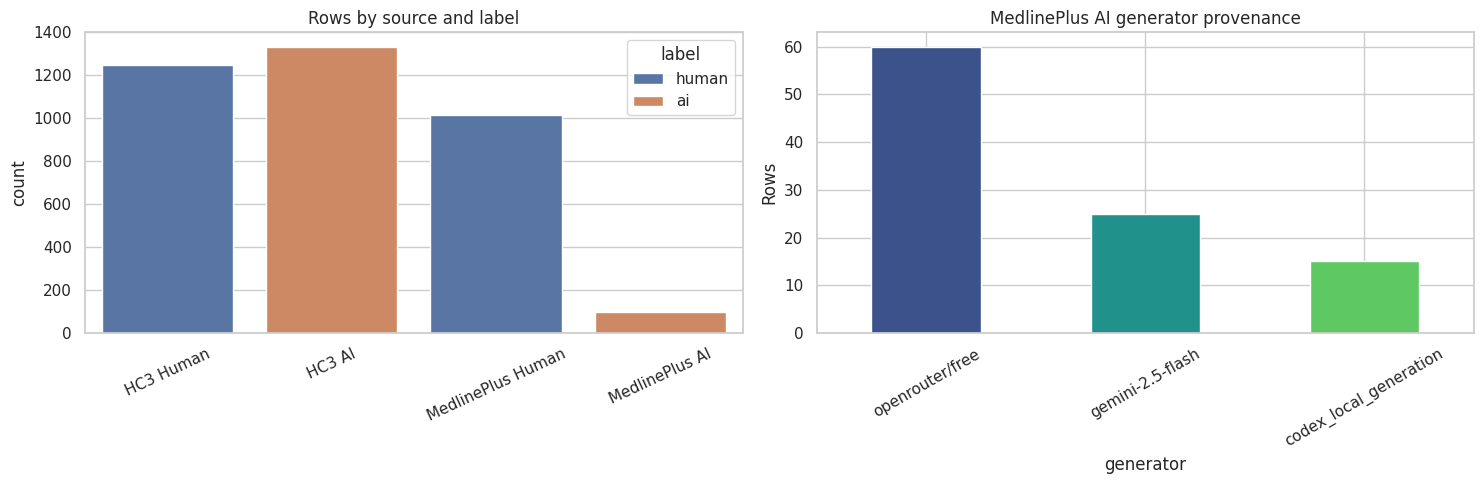

,rows
generator,
openrouter/free,60
gemini-2.5-flash,25
codex_local_generation,15


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=eda, x="analysis_group", hue="label", ax=axes[0])
axes[0].set_title("Rows by source and label")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_xlabel("")

generator_counts = (
    eda.loc[eda["analysis_group"].eq("MedlinePlus AI"), "generator"]
    .fillna("unknown")
    .value_counts()
)
generator_counts.plot(kind="bar", ax=axes[1], color=sns.color_palette("viridis", len(generator_counts)))
axes[1].set_title("MedlinePlus AI generator provenance")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_source_generator_counts.png", dpi=160, bbox_inches="tight")
plt.show()

display(generator_counts.rename("rows").to_frame())

## 4. Length and stylometric distributions

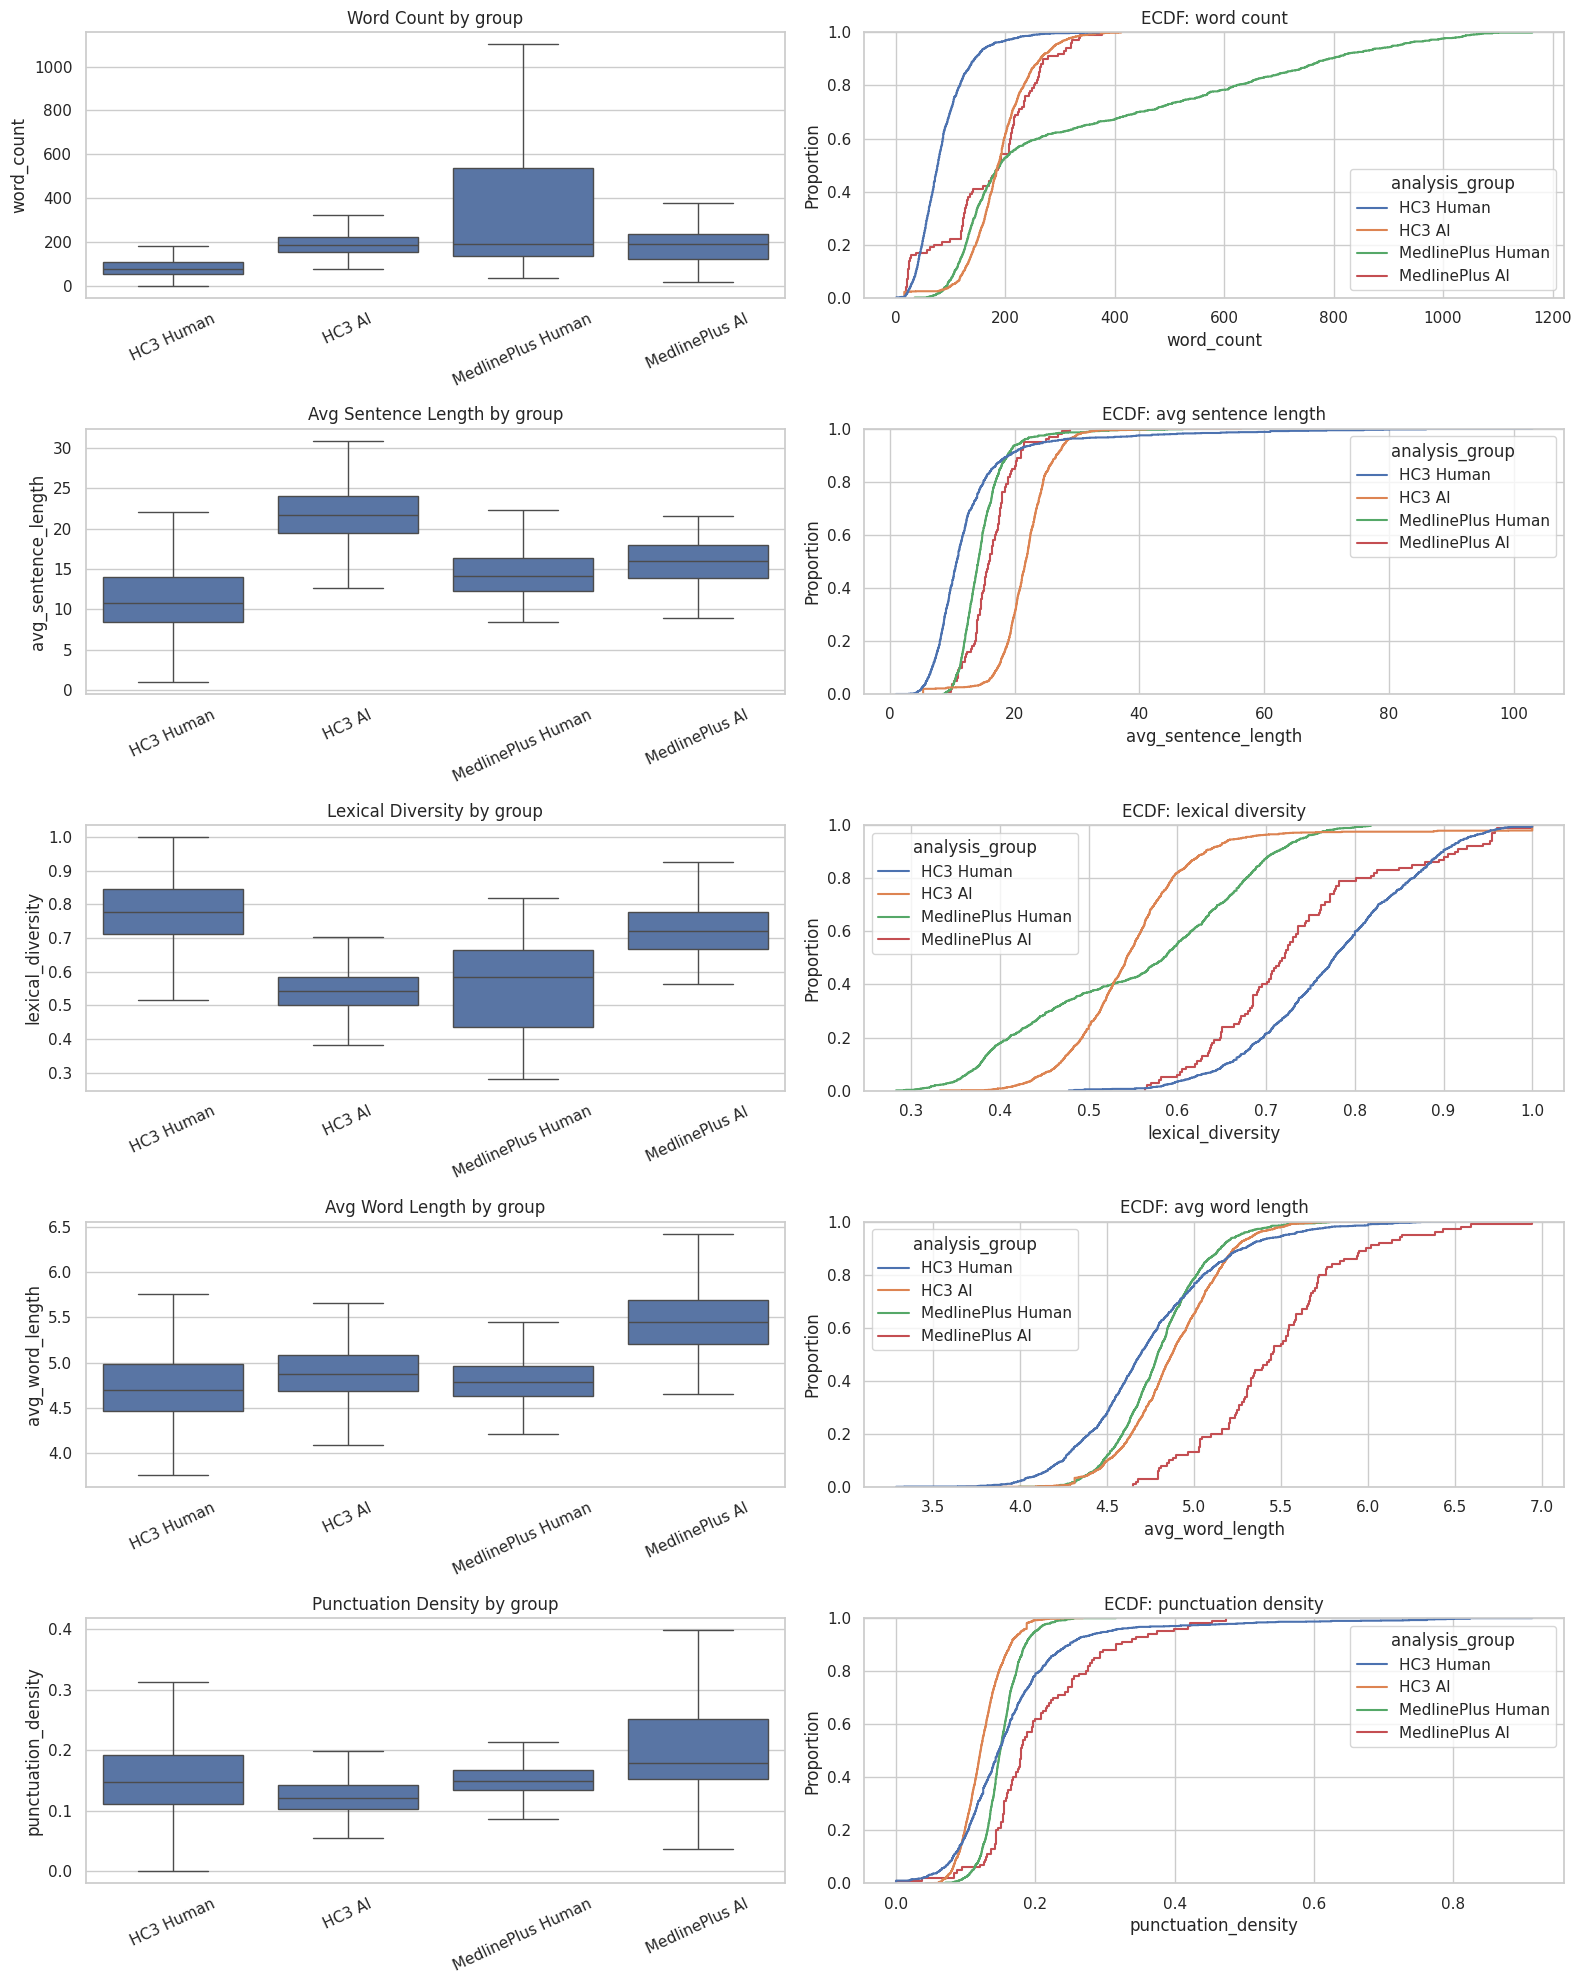

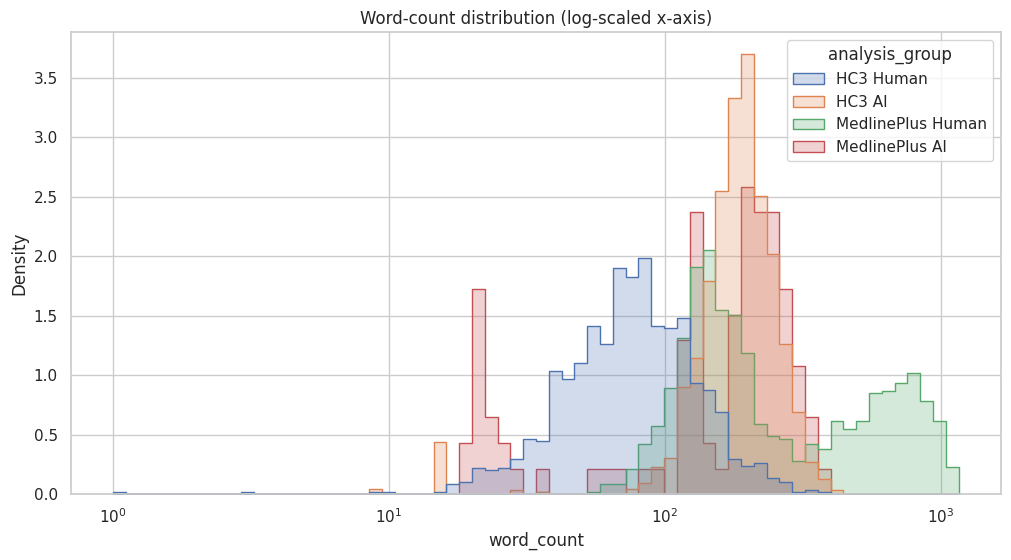

In [8]:
plot_features = [
    "word_count",
    "avg_sentence_length",
    "lexical_diversity",
    "avg_word_length",
    "punctuation_density",
]

fig, axes = plt.subplots(len(plot_features), 2, figsize=(16, 4 * len(plot_features)))

for row, feature in enumerate(plot_features):
    sns.boxplot(data=eda, x="analysis_group", y=feature, ax=axes[row, 0], showfliers=False)
    axes[row, 0].tick_params(axis="x", rotation=25)
    axes[row, 0].set_xlabel("")
    axes[row, 0].set_title(f"{feature.replace('_', ' ').title()} by group")

    sns.ecdfplot(data=eda, x=feature, hue="analysis_group", ax=axes[row, 1])
    axes[row, 1].set_title(f"ECDF: {feature.replace('_', ' ')}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "linguistic_feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(
    data=eda,
    x="word_count",
    hue="analysis_group",
    element="step",
    stat="density",
    common_norm=False,
    log_scale=(True, False),
)
plt.title("Word-count distribution (log-scaled x-axis)")
plt.savefig(OUTPUT_DIR / "word_count_log_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Statistical distribution-shift tests

In [9]:
def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled if pooled else np.nan


comparisons = [
    ("HC3 Human", "HC3 AI"),
    ("MedlinePlus Human", "MedlinePlus AI"),
    ("HC3 Human", "MedlinePlus Human"),
    ("HC3 AI", "MedlinePlus AI"),
]

test_rows = []
for left, right in comparisons:
    for feature in plot_features:
        a = eda.loc[eda["analysis_group"].eq(left), feature].dropna()
        b = eda.loc[eda["analysis_group"].eq(right), feature].dropna()
        statistic, p_value = ttest_ind(a, b, equal_var=False)
        test_rows.append(
            {
                "comparison": f"{left} vs {right}",
                "feature": feature,
                "mean_left": a.mean(),
                "mean_right": b.mean(),
                "welch_t": statistic,
                "p_value": p_value,
                "cohens_d": cohens_d(a, b),
            }
        )

tests = pd.DataFrame(test_rows)
tests["significant_0.05"] = tests["p_value"] < 0.05
display(tests.round(5))
tests.to_csv(OUTPUT_DIR / "welch_tests_and_effect_sizes.csv", index=False)

,comparison,feature,mean_left,mean_right,welch_t,p_value,cohens_d,significant_0.05
0,HC3 Human vs HC3 AI,word_count,85.89824,189.68891,-49.27546,0.00000,-1.92624,True
1,HC3 Human vs HC3 AI,avg_sentence_length,12.89019,21.69189,-29.89459,0.00000,-1.20212,True
2,HC3 Human vs HC3 AI,lexical_diversity,0.77691,0.55324,61.01074,0.00000,2.40426,True
3,HC3 Human vs HC3 AI,avg_word_length,4.73967,4.88046,-9.69548,0.00000,-0.38664,True
4,HC3 Human vs HC3 AI,punctuation_density,0.16492,0.12412,13.63826,0.00000,0.55236,True
5,MedlinePlus Human vs MedlinePlus AI,word_count,341.51378,171.72000,13.38226,0.00000,0.63996,True
6,MedlinePlus Human vs MedlinePlus AI,avg_sentence_length,14.85676,16.29046,-3.53913,0.00057,-0.35009,True
7,MedlinePlus Human vs MedlinePlus AI,lexical_diversity,0.55590,0.73583,-16.03196,0.00000,-1.41587,True
8,MedlinePlus Human vs MedlinePlus AI,avg_word_length,4.80686,5.46849,-14.82123,0.00000,-2.31526,True
9,MedlinePlus Human vs MedlinePlus AI,punctuation_density,0.15188,0.20536,-6.24310,0.00000,-1.45223,True


## 6. Opening-style and lexical artifact analysis

In [10]:
def first_words(text, n=12):
    return " ".join(str(text).split()[:n]).lower()


opening_rates = (
    eda.groupby("analysis_group")[["starts_with_greeting", "starts_with_heading"]]
    .mean()
    .mul(100)
    .round(2)
)
display(opening_rates.rename(columns=lambda c: c + "_pct"))

for group in eda["analysis_group"].unique():
    print(f"\n{group}: example openings")
    display(eda.loc[eda["analysis_group"].eq(group), "text"].head(5).map(first_words).to_frame("opening"))

hc3_only = eda.loc[eda["dataset_group"].eq("HC3")].copy()
vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=3, max_features=20_000, stop_words="english")
X = vectorizer.fit_transform(hc3_only["text"])
y = hc3_only["label"].eq("ai").astype(int)

lexical_model = LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE)
lexical_model.fit(X, y)
names = vectorizer.get_feature_names_out()
coefs = lexical_model.coef_[0]

top_ai_idx = np.argsort(coefs)[-25:][::-1]
top_human_idx = np.argsort(coefs)[:25]
lexical_table = pd.DataFrame(
    {
        "AI-associated feature": names[top_ai_idx],
        "AI coefficient": coefs[top_ai_idx],
        "Human-associated feature": names[top_human_idx],
        "Human coefficient": coefs[top_human_idx],
    }
)
display(lexical_table)
lexical_table.to_csv(OUTPUT_DIR / "hc3_lexical_artifacts.csv", index=False)

,starts_with_greeting_pct,starts_with_heading_pct
analysis_group,,
HC3 AI,0.00,0.0
HC3 Human,75.64,0.0
MedlinePlus AI,0.00,8.0
MedlinePlus Human,0.00,0.0



HC3 Human: example openings


,opening
0,"hi, thanks for the query. i understand your co..."
2,"hello,thanks for the query to h.c.m. forum.pai..."
4,"hello, the use of clindamycin can cause stomac..."
6,hello. revert back with the photos to a dentis...
8,"hi dear,welcome to healthcaremagic team.unders..."



HC3 AI: example openings


,opening
1,it is not recommended to use primolut n during...
3,if you are experiencing abdominal pain and blo...
5,it is possible that chest pain could be relate...
7,it is difficult to accurately diagnose a condi...
9,i'm sorry to hear that you're feeling sick. it...



MedlinePlus Human: example openings


,opening
2582,a1c is a blood test for type 2 diabetes and pr...
2583,your abdomen extends from below your chest to ...
2584,an induced abortion is a procedure to end a pr...
2585,an abscess is a pocket of pus. you can get an ...
2586,acne is a common skin disease that causes pimp...



MedlinePlus AI: example openings


,opening
3598,"# understanding your a1c test the a1c test, al..."
3599,abdominal pain refersto discomfort or pain exp...
3600,"abortion refers to the end of a pregnancy, inv..."
3601,**understandingan abscess** an abscess is a lo...
3602,# understanding acne acne is a common skin con...


,AI-associated feature,AI coefficient,Human-associated feature,Human coefficient
0,important,1.678780,hi,-0.793799
1,error,1.256676,hope,-0.629877
2,generating,0.977254,hello,-0.608667
3,error generating,0.977254,thanks,-0.404398
4,generating response,0.977254,query,-0.401103
5,response,0.918805,like,-0.400233
6,healthcare,0.739841,dr,-0.399167
7,possible,0.598322,need,-0.367512
8,provider,0.596813,regards,-0.349985
9,determine,0.593578,question,-0.255415


## 7. Exploratory baseline and external transfer check

In [11]:
hc3_train, hc3_test = train_test_split(
    hc3_only,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=hc3_only["label"],
)

vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=30_000)
X_train = vectorizer.fit_transform(hc3_train["text"])
X_test = vectorizer.transform(hc3_test["text"])

model = LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE)
model.fit(X_train, hc3_train["label"])

internal_pred = model.predict(X_test)
print("HC3 random holdout accuracy:", round(accuracy_score(hc3_test["label"], internal_pred), 4))

external = eda.loc[eda["analysis_group"].isin(["MedlinePlus Human", "MedlinePlus AI"])].copy()
external_pred = model.predict(vectorizer.transform(external["text"]))
print("External MedlinePlus accuracy:", round(accuracy_score(external["label"], external_pred), 4))
print(classification_report(external["label"], external_pred, zero_division=0))
print("Confusion matrix labels [ai, human]:")
print(confusion_matrix(external["label"], external_pred, labels=["ai", "human"]))

print("\nInterpret this as distribution-shift evidence, not a final benchmark: the random HC3 split shares source artifacts.")

HC3 random holdout accuracy: 0.9974
External MedlinePlus accuracy: 0.4767
              precision    recall  f1-score   support

          ai       0.10      0.63      0.18       100
       human       0.93      0.46      0.62      1016

    accuracy                           0.48      1116
   macro avg       0.52      0.55      0.40      1116
weighted avg       0.85      0.48      0.58      1116

Confusion matrix labels [ai, human]:
[[ 63  37]
 [547 469]]

Interpret this as distribution-shift evidence, not a final benchmark: the random HC3 split shares source artifacts.


## 8. Cross-source TF-IDF evaluation

,split,source_dataset,label,rows
0,test,medlineplus,human,305
1,test,medlineplus_llm_generated,ai,17
2,test,medlineplus_openrouter_generated,ai,15
3,train,hc3,ai,933
4,train,hc3,human,873
5,train,medlineplus,human,711
6,train,medlineplus_llm_generated,ai,23
7,train,medlineplus_openrouter_generated,ai,45


Cross-source train rows: 2,585
Held-out MedlinePlus test rows: 337
Accuracy: 0.9466
ROC-AUC: 0.9587
              precision    recall  f1-score   support

          ai       1.00      0.44      0.61        32
       human       0.94      1.00      0.97       305

    accuracy                           0.95       337
   macro avg       0.97      0.72      0.79       337
weighted avg       0.95      0.95      0.94       337

Confusion matrix labels [ai, human]:
[[ 14  18]
 [  0 305]]


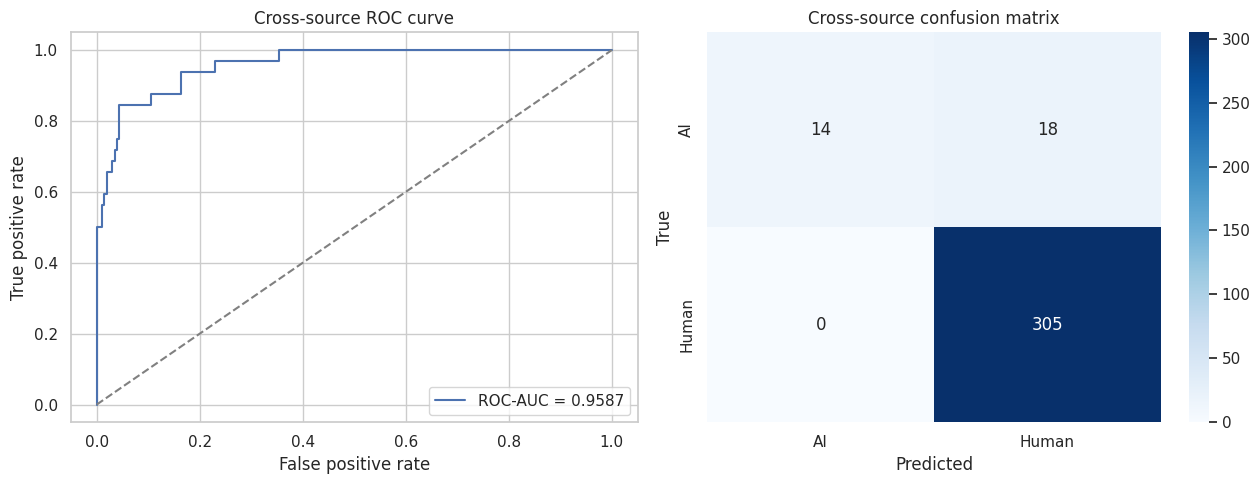

In [12]:
def grouped_train_test_split(frame, train_ratio, random_state=42):
    group_ids = list(dict.fromkeys(frame["split_group"].tolist()))
    random.Random(random_state).shuffle(group_ids)
    split_index = int(len(group_ids) * train_ratio)
    train_groups = set(group_ids[:split_index])
    train = frame.loc[frame["split_group"].isin(train_groups)].copy()
    test = frame.loc[~frame["split_group"].isin(train_groups)].copy()
    return train, test


# Reproduce the project split logic from the three uploaded base datasets.
hc3_train, hc3_remainder = grouped_train_test_split(hc3, train_ratio=0.70)
medlineplus_all = pd.concat([mp_human, mp_ai], ignore_index=True, sort=False)
medlineplus_train, medlineplus_test = grouped_train_test_split(
    medlineplus_all, train_ratio=0.70
)

cross_train = pd.concat([hc3_train, medlineplus_train], ignore_index=True, sort=False)
cross_test = medlineplus_test.reset_index(drop=True)

assert set(cross_train["split_group"]).isdisjoint(set(cross_test["split_group"]))

split_composition = (
    pd.concat(
        [
            cross_train.assign(split="train"),
            cross_test.assign(split="test"),
        ],
        ignore_index=True,
    )
    .groupby(["split", "source_dataset", "label"])
    .size()
    .rename("rows")
    .reset_index()
)
display(split_composition)
print(f"Cross-source train rows: {len(cross_train):,}")
print(f"Held-out MedlinePlus test rows: {len(cross_test):,}")

cross_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=20_000,
    stop_words="english",
)
X_cross_train = cross_vectorizer.fit_transform(cross_train["text"])
X_cross_test = cross_vectorizer.transform(cross_test["text"])

cross_model = LogisticRegression(
    max_iter=1_000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
cross_model.fit(X_cross_train, cross_train["label"])

cross_pred = cross_model.predict(X_cross_test)
classes = list(cross_model.classes_)
ai_index = classes.index("ai")
ai_probability = cross_model.predict_proba(X_cross_test)[:, ai_index]
y_binary = cross_test["label"].eq("ai").astype(int).to_numpy()

cross_accuracy = accuracy_score(cross_test["label"], cross_pred)
cross_roc_auc = roc_auc_score(y_binary, ai_probability)
cross_confusion = confusion_matrix(
    cross_test["label"], cross_pred, labels=["ai", "human"]
)

print(f"Accuracy: {cross_accuracy:.4f}")
print(f"ROC-AUC: {cross_roc_auc:.4f}")
print(classification_report(cross_test["label"], cross_pred, zero_division=0))
print("Confusion matrix labels [ai, human]:")
print(cross_confusion)

fpr, tpr, _ = roc_curve(y_binary, ai_probability)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {cross_roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="Cross-source ROC curve")
axes[0].legend()

sns.heatmap(
    cross_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["AI", "Human"],
    yticklabels=["AI", "Human"],
    ax=axes[1],
)
axes[1].set(xlabel="Predicted", ylabel="True", title="Cross-source confusion matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_source_roc_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

In [13]:
threshold_rows = []
for threshold in np.arange(0.10, 0.61, 0.05):
    threshold_pred = np.where(ai_probability >= threshold, "ai", "human")
    precision, recall, f1, _ = precision_recall_fscore_support(
        cross_test["label"],
        threshold_pred,
        labels=["ai", "human"],
        zero_division=0,
    )
    threshold_rows.append(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(cross_test["label"], threshold_pred),
            "ai_precision": precision[0],
            "ai_recall": recall[0],
            "ai_f1": f1[0],
            "human_recall": recall[1],
        }
    )

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(4))
threshold_table.to_csv(OUTPUT_DIR / "cross_source_threshold_sweep.csv", index=False)

feature_names = cross_vectorizer.get_feature_names_out()
coefficients = cross_model.coef_[0]
# sklearn classes are ['ai', 'human']; positive coefficients indicate human.
top_human = np.argsort(coefficients)[-25:][::-1]
top_ai = np.argsort(coefficients)[:25]
cross_features = pd.DataFrame(
    {
        "human_feature": feature_names[top_human],
        "human_coefficient": coefficients[top_human],
        "ai_feature": feature_names[top_ai],
        "ai_coefficient": coefficients[top_ai],
    }
)
display(cross_features)
cross_features.to_csv(OUTPUT_DIR / "cross_source_top_features.csv", index=False)

cross_metrics = pd.DataFrame(
    [
        {
            "train_rows": len(cross_train),
            "test_rows": len(cross_test),
            "accuracy": cross_accuracy,
            "roc_auc": cross_roc_auc,
            "ai_true_positive": int(cross_confusion[0, 0]),
            "ai_false_negative": int(cross_confusion[0, 1]),
            "human_false_positive": int(cross_confusion[1, 0]),
            "human_true_negative": int(cross_confusion[1, 1]),
        }
    ]
)
display(cross_metrics.round(4))
cross_metrics.to_csv(OUTPUT_DIR / "cross_source_metrics.csv", index=False)

,threshold,accuracy,ai_precision,ai_recall,ai_f1,human_recall
0,0.10,0.1573,0.1013,1.0000,0.1839,0.0689
1,0.15,0.3709,0.1311,1.0000,0.2319,0.3049
2,0.20,0.6499,0.2133,1.0000,0.3516,0.6131
3,0.25,0.8338,0.3571,0.9375,0.5172,0.8230
4,0.30,0.9407,0.6429,0.8438,0.7297,0.9508
5,0.35,0.9466,0.7917,0.5938,0.6786,0.9836
6,0.40,0.9466,0.8500,0.5312,0.6538,0.9902
7,0.45,0.9496,1.0000,0.4688,0.6383,1.0000
8,0.50,0.9466,1.0000,0.4375,0.6087,1.0000
9,0.55,0.9318,1.0000,0.2812,0.4390,1.0000


,human_feature,human_coefficient,ai_feature,ai_coefficient
0,hi,2.622790,important,-5.763874
1,medicines,2.087253,healthcare,-4.529125
2,hope,2.001926,healthcare provider,-3.856163
3,query,1.963012,determine,-3.074947
4,need,1.953081,possible,-2.786767
5,hello,1.867012,medications,-2.691644
6,thanks,1.803260,treatment,-2.608541
7,dr,1.578173,professional,-2.287651
8,health care,1.572307,cause,-2.168305
9,care,1.505316,appropriate,-2.128690


,train_rows,test_rows,accuracy,roc_auc,ai_true_positive,ai_false_negative,human_false_positive,human_true_negative
0,2585,337,0.9466,0.9587,14,18,0,305


### Cross-source interpretation

The expected current-project result is approximately **94.66% accuracy** and
**95.87% ROC-AUC** on 337 held-out MedlinePlus rows. At the default threshold,
human recall is very high but AI recall is low. The threshold sweep shows why
calibration is necessary, while the coefficient table reveals that source/style
artifacts remain present even after cross-source training.

## 9. Export EDA tables and figures

In [14]:
export_columns = [
    "id", "label", "dataset_group", "analysis_group", "source_document_id",
    "medical_topic", "generator", *feature_columns,
]
eda[[c for c in export_columns if c in eda.columns]].to_csv(
    OUTPUT_DIR / "text_level_eda_features.csv", index=False
)
audit.to_csv(OUTPUT_DIR / "dataset_audit.csv")
summary.to_csv(OUTPUT_DIR / "group_feature_summary.csv")

import shutil
archive = shutil.make_archive("/content/medical_text_eda_outputs", "zip", OUTPUT_DIR)
print("Created:", archive)
print("Output files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)

Created: /content/medical_text_eda_outputs.zip
Output files:
 - class_source_generator_counts.png
 - cross_source_metrics.csv
 - cross_source_roc_confusion.png
 - cross_source_threshold_sweep.csv
 - cross_source_top_features.csv
 - dataset_audit.csv
 - group_feature_summary.csv
 - hc3_lexical_artifacts.csv
 - linguistic_feature_distributions.png
 - text_level_eda_features.csv
 - welch_tests_and_effect_sizes.csv
 - word_count_log_distribution.png


## Interpretation checklist

Before drawing conclusions, check:

1. Are source and label confounded?
2. Are human and AI texts length-matched?
3. Are paired texts kept in the same split via `source_document_id`?
4. Does performance transfer from HC3 to MedlinePlus?
5. Are generator-specific artifacts driving the result?
6. Is class imbalance making accuracy misleading?